First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Shape:
(891, 15)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ----

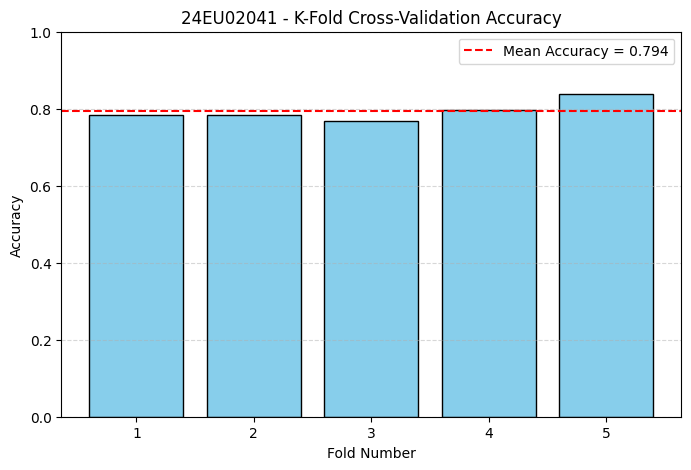


================ GRID SEARCH ================

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}

Best Cross-Validation Accuracy:
0.8259

Top 10 Grid Search Results:
    mean_test_score  std_test_score  param_classifier__n_estimators  \
6          0.825914        0.023533                              50   
35         0.823097        0.019957                             200   
28         0.821728        0.030671                             100   
32         0.821708        0.026313                             200   
7          0.821698        0.021888                             100   
31         0.820319        0.029713                             100   
10         0.820290        0.023248                             100   
18         0.820290        0.031216                              50   
34         0.820290        0.023648                             100   
9          0.818911  

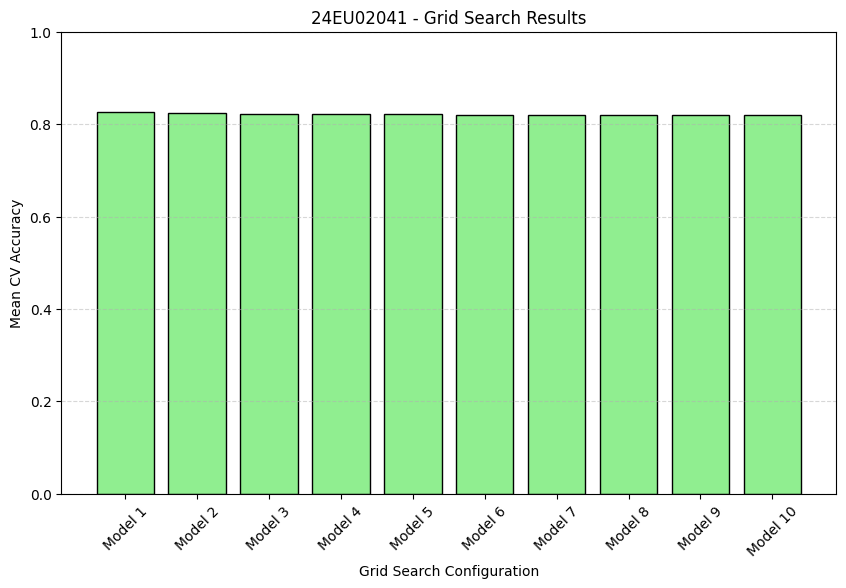


================ FINAL MODEL EVALUATION ================
Test Accuracy: 0.8045

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



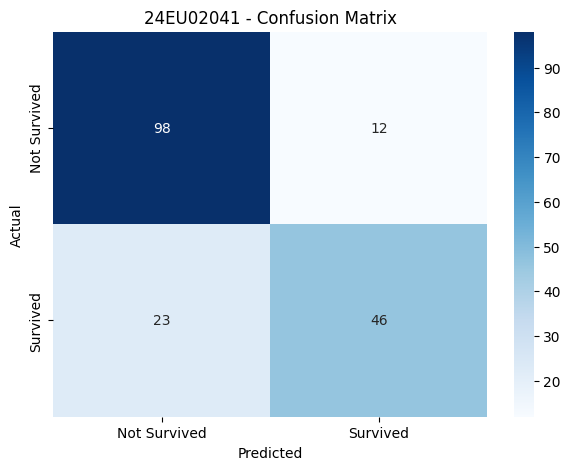


================ SUMMARY ================
K-Fold Mean Accuracy: 0.7936
Best Grid Search Accuracy: 0.8259
Final Test Accuracy: 0.8045

Best Parameters:
classifier__max_depth: None
classifier__min_samples_leaf: 2
classifier__min_samples_split: 2
classifier__n_estimators: 50


In [1]:
# ============================================================
# TITANIC DATASET - K-FOLD CROSS VALIDATION & GRID SEARCH
# ============================================================

# 1. Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. Load Titanic Dataset
# ============================================================

df = sns.load_dataset("titanic")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 3. Select Features and Target
# ============================================================

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]
y = df["survived"]


# ============================================================
# 4. Define Numerical and Categorical Features
# ============================================================

numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked"
]


# ============================================================
# 5. Preprocessing
# ============================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# ============================================================
# 6. Create Random Forest Model
# ============================================================

model = RandomForestClassifier(
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", model)
])


# ============================================================
# 7. Split Dataset into Training and Testing Data
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# 8. K-FOLD CROSS VALIDATION
# ============================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring="accuracy"
)

print("\n================ K-FOLD CROSS VALIDATION ================")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i} Accuracy: {score:.4f}")

print(f"\nMean K-Fold Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


# ============================================================
# 9. GRAPH - K-FOLD ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

fold_numbers = range(1, 6)

plt.bar(
    fold_numbers,
    cv_scores,
    color="skyblue",
    edgecolor="black"
)

plt.axhline(
    cv_scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean Accuracy = {cv_scores.mean():.3f}"
)

plt.xlabel("Fold Number")
plt.ylabel("Accuracy")

plt.title(
    "24EU02041 - K-Fold Cross-Validation Accuracy"
)

plt.xticks(fold_numbers)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


# ============================================================
# 10. GRID SEARCH
# ============================================================

param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train
)


# ============================================================
# 11. Display Grid Search Results
# ============================================================

print("\n================ GRID SEARCH ================")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")


# ============================================================
# 12. Display Top Grid Search Results
# ============================================================

results = pd.DataFrame(
    grid_search.cv_results_
)

results = results.sort_values(
    by="mean_test_score",
    ascending=False
)

print("\nTop 10 Grid Search Results:")

print(
    results[
        [
            "mean_test_score",
            "std_test_score",
            "param_classifier__n_estimators",
            "param_classifier__max_depth",
            "param_classifier__min_samples_split",
            "param_classifier__min_samples_leaf"
        ]
    ].head(10)
)


# ============================================================
# 13. GRAPH - GRID SEARCH RESULTS
# ============================================================

top_results = results.head(10).copy()

top_results["configuration"] = [
    f"Model {i+1}" for i in range(len(top_results))
]

plt.figure(figsize=(10, 6))

plt.bar(
    top_results["configuration"],
    top_results["mean_test_score"],
    color="lightgreen",
    edgecolor="black"
)

plt.xlabel("Grid Search Configuration")
plt.ylabel("Mean CV Accuracy")

plt.title(
    "24EU02041 - Grid Search Results"
)

plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


# ============================================================
# 14. Train Best Model
# ============================================================

best_model = grid_search.best_estimator_

best_model.fit(
    X_train,
    y_train
)


# ============================================================
# 15. Prediction on Test Data
# ============================================================

y_pred = best_model.predict(X_test)


# ============================================================
# 16. Model Evaluation
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n================ FINAL MODEL EVALUATION ================")

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "24EU02041 - Confusion Matrix"
)

plt.show()


# ============================================================
# 18. SUMMARY
# ============================================================

print("\n================ SUMMARY ================")

print(
    f"K-Fold Mean Accuracy: {cv_scores.mean():.4f}"
)

print(
    f"Best Grid Search Accuracy: {grid_search.best_score_:.4f}"
)

print(
    f"Final Test Accuracy: {test_accuracy:.4f}"
)

print("\nBest Parameters:")
for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")
